# Visualization 02 Retention Overview

Converted from `visualizations/02_retention_overview.py`. 


In [1]:
# Notebook bootstrap generated from visualizations/02_retention_overview.py
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data_cleaning' else Path.cwd()
VISUALIZATIONS_DIR = PROJECT_ROOT / 'visualizations'
if str(VISUALIZATIONS_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATIONS_DIR))
os.chdir(VISUALIZATIONS_DIR)
__file__ = str(VISUALIZATIONS_DIR / '02_retention_overview.py')

from IPython.display import display

def inline_save(fig, name):
    display(fig)
    try:
        import matplotlib.pyplot as plt
        plt.close(fig)
    except Exception:
        pass
    print(f"  Displayed inline: {name}")
    return None


In [2]:
"""
02_retention_overview.py
Charts: repeat rate by channel, repeat rate by product, time-to-2nd-purchase,
        monthly cohort 60-day retention
"""
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from style import save, TEAL, NAVY, ORANGE, RED, SLATE, GOLD, LIGHT_BG, LILAC, bar_label, hbar_label

# Notebook override: display charts inline instead of writing PNG files.
save = inline_save



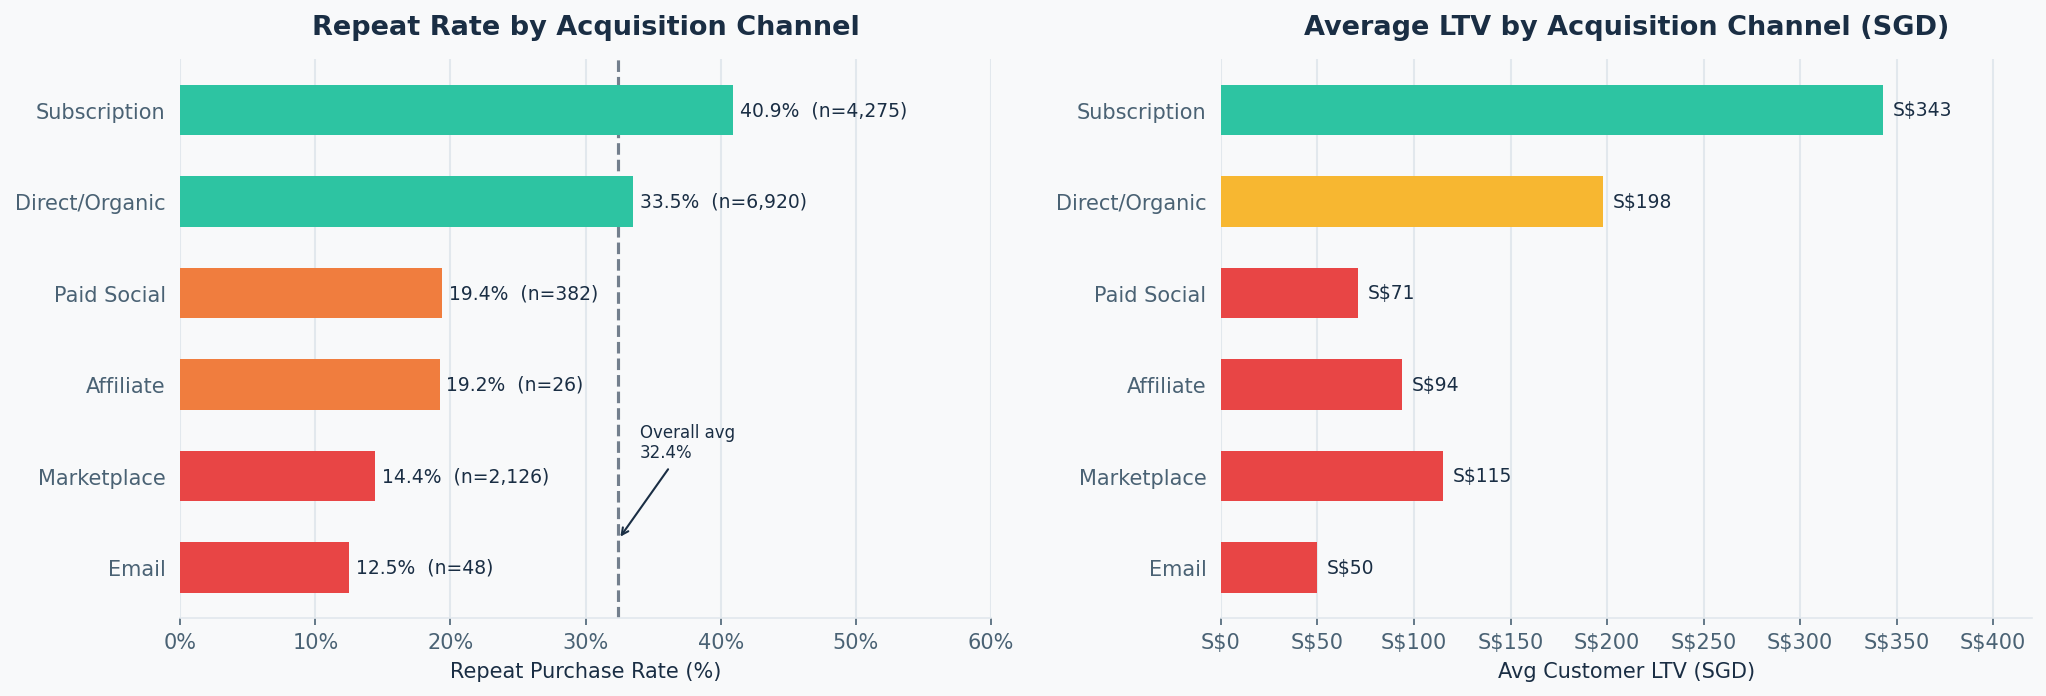

  Displayed inline: 02a_retention_by_channel


In [3]:
# ── Chart 1: Repeat rate + avg LTV by channel (side-by-side horizontal) ──────
channels      = ["Subscription","Direct/Organic","Paid Social","Affiliate","Marketplace","Email"]
repeat_rates  = [40.9, 33.5, 19.4, 19.2, 14.4, 12.5]
avg_ltv       = [343, 198, 71, 94, 115, 50]
n_customers   = [4275, 6920, 382, 26, 2126, 48]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Repeat rate
colors_rr = [TEAL if r > 25 else ORANGE if r > 15 else RED for r in repeat_rates]
axes[0].barh(channels[::-1], repeat_rates[::-1], color=colors_rr[::-1], height=0.55, zorder=3)
axes[0].set_title("Repeat Rate by Acquisition Channel", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Repeat Purchase Rate (%)", fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
axes[0].axvline(32.4, color=NAVY, linewidth=1.5, linestyle="--", alpha=0.6)
axes[0].annotate("Overall avg\n32.4%", xy=(32.4, 0.3), xytext=(34, 1.2),
                 fontsize=8, color=NAVY, arrowprops=dict(arrowstyle="->", color=NAVY, lw=1))
for i, (v, n) in enumerate(zip(repeat_rates[::-1], n_customers[::-1])):
    axes[0].text(v+0.5, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=9, color=NAVY)
axes[0].set_xlim(0, 60)
axes[0].spines["left"].set_visible(False); axes[0].tick_params(left=False)

# Avg LTV
ltv_colors = [TEAL if l > 300 else GOLD if l > 150 else RED for l in avg_ltv]
axes[1].barh(channels[::-1], avg_ltv[::-1], color=ltv_colors[::-1], height=0.55, zorder=3)
axes[1].set_title("Average LTV by Acquisition Channel (SGD)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Avg Customer LTV (SGD)", fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:.0f}"))
for i, v in enumerate(avg_ltv[::-1]):
    axes[1].text(v+5, i, f"S${v:,}", va="center", fontsize=9, color=NAVY)
axes[1].set_xlim(0, 420)
axes[1].spines["left"].set_visible(False); axes[1].tick_params(left=False)

for ax in axes:
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)

fig.tight_layout(pad=2)
save(fig, "02a_retention_by_channel")



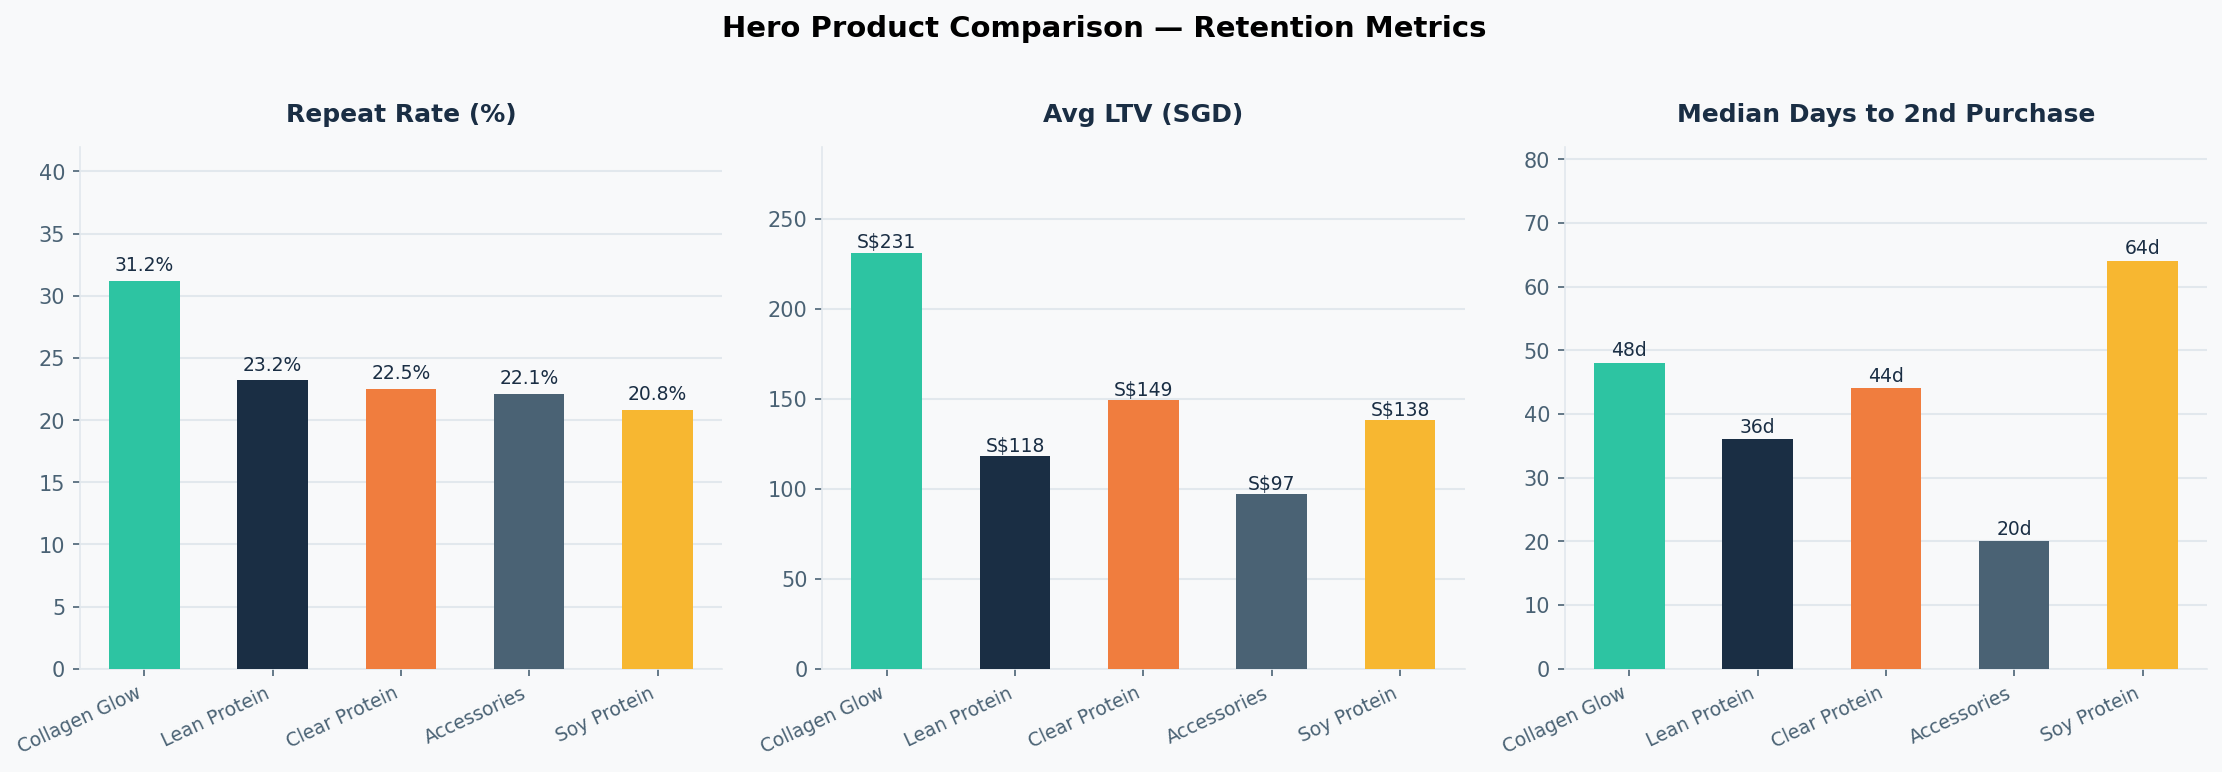

  Displayed inline: 02b_retention_by_product


In [4]:
# ── Chart 2: Repeat rate by first product (with avg LTV and median days) ─────
products     = ["Collagen Glow","Lean Protein","Clear Protein","Accessories","Soy Protein"]
prod_rr      = [31.2, 23.2, 22.5, 22.1, 20.8]
prod_ltv     = [231, 118, 149, 97, 138]
prod_days    = [48, 36, 44, 20, 64]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
prod_colors = [TEAL, NAVY, ORANGE, SLATE, GOLD]

for ax, vals, title, fmt, suffix in [
    (axes[0], prod_rr,  "Repeat Rate (%)",           "{:.1f}%", "%"),
    (axes[1], prod_ltv, "Avg LTV (SGD)",              "S${:.0f}", ""),
    (axes[2], prod_days,"Median Days to 2nd Purchase","{}d",     ""),
]:
    x = np.arange(len(products))
    bars = ax.bar(x, vals, color=prod_colors, width=0.55, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(products, rotation=25, ha="right", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                fmt.format(v), ha="center", va="bottom", fontsize=9, color=NAVY)

axes[0].set_ylim(0, 42)
axes[1].set_ylim(0, 290)
axes[2].set_ylim(0, 82)
fig.suptitle("Hero Product Comparison — Retention Metrics", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "02b_retention_by_product")



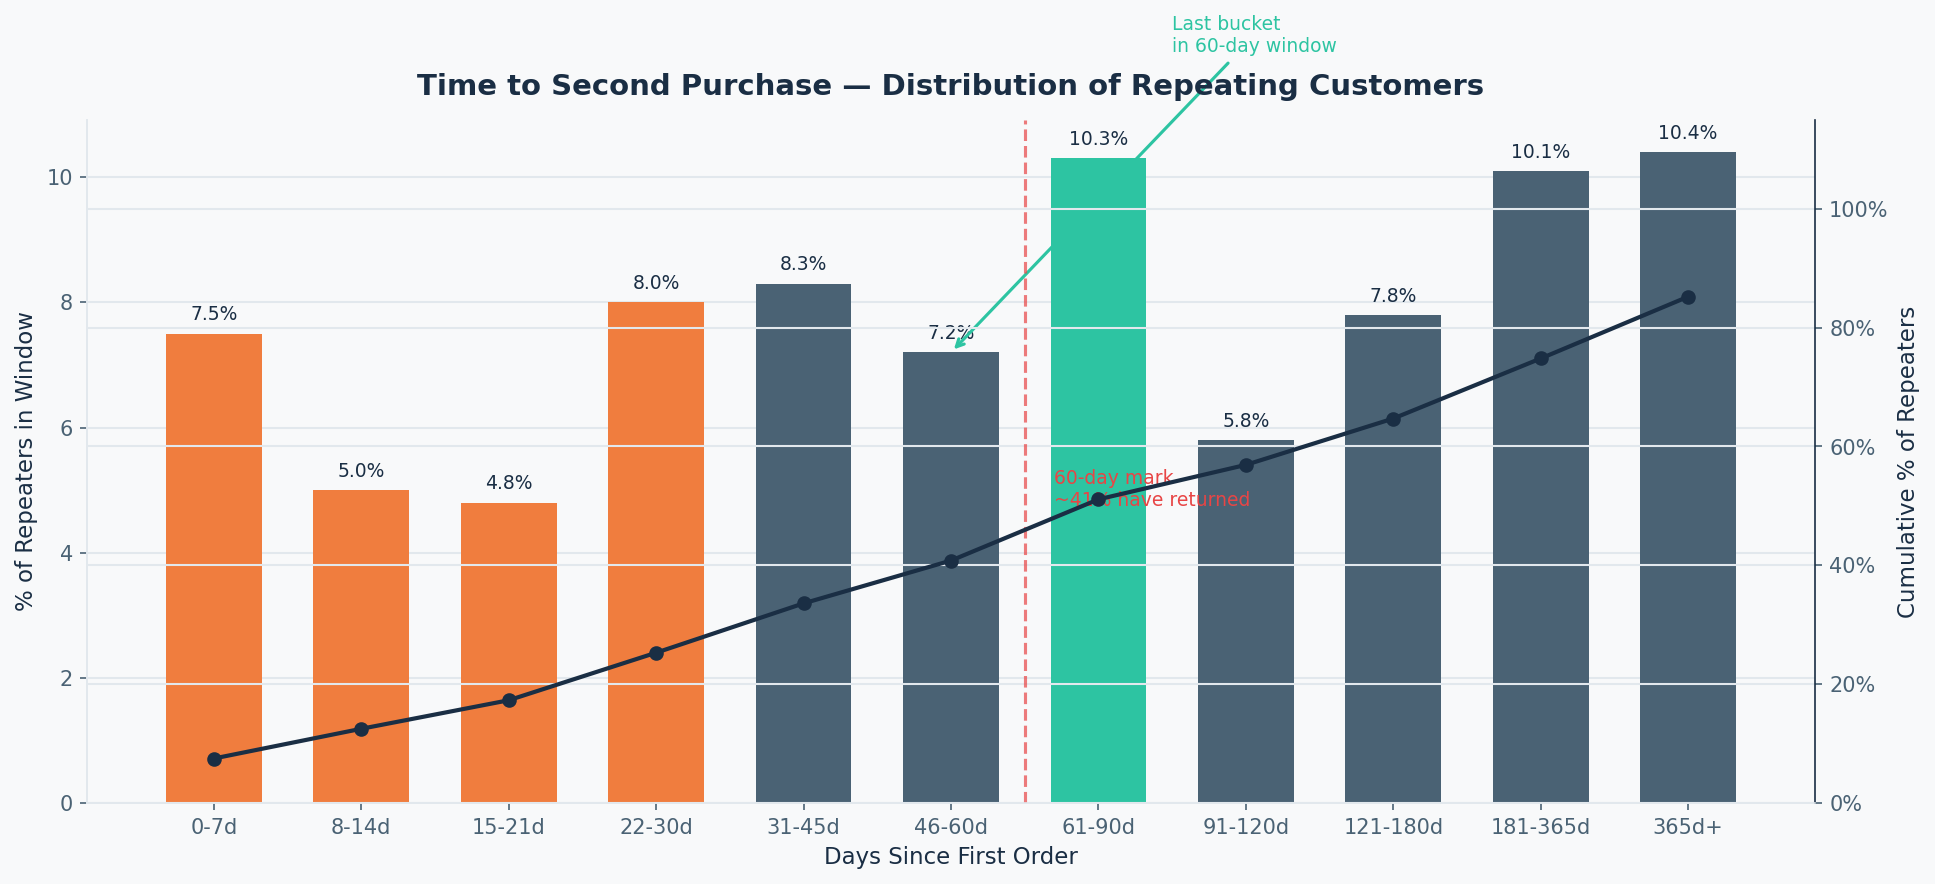

  Displayed inline: 02c_time_to_second_purchase


In [5]:
# ── Chart 3: Time-to-second-purchase histogram ────────────────────────────────
buckets = ["0-7d","8-14d","15-21d","22-30d","31-45d","46-60d","61-90d","91-120d","121-180d","181-365d","365d+"]
pct     = [7.5, 5.0, 4.8, 8.0, 8.3, 7.2, 10.3, 5.8, 7.8, 10.1, 10.4]
cumulative = np.cumsum(pct)

fig, ax1 = plt.subplots(figsize=(13, 6))
bar_colors = [TEAL if i == 6 else (ORANGE if i < 4 else SLATE) for i in range(len(buckets))]
bars = ax1.bar(buckets, pct, color=bar_colors, width=0.65, zorder=3)
ax1.set_title("Time to Second Purchase — Distribution of Repeating Customers")
ax1.set_ylabel("% of Repeaters in Window", fontsize=11)
ax1.set_xlabel("Days Since First Order", fontsize=11)
for bar, v in zip(bars, pct):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color=NAVY)

ax2 = ax1.twinx()
ax2.plot(buckets, cumulative, color=NAVY, marker="o", linewidth=2, markersize=6, zorder=4)
ax2.set_ylabel("Cumulative % of Repeaters", color=NAVY, fontsize=11)
ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(NAVY)
# Annotate 60-day mark
ax2.axvline(x=5.5, color=RED, linestyle="--", linewidth=1.5, alpha=0.7)
ax2.text(5.7, 50, "60-day mark\n~41% have returned", color=RED, fontsize=9)

# Highlight 46-60d bar
ax1.annotate("Last bucket\nin 60-day window", xy=(5, pct[5]), xytext=(6.5, 12),
             arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.5), color=TEAL, fontsize=9)

fig.tight_layout()
save(fig, "02c_time_to_second_purchase")



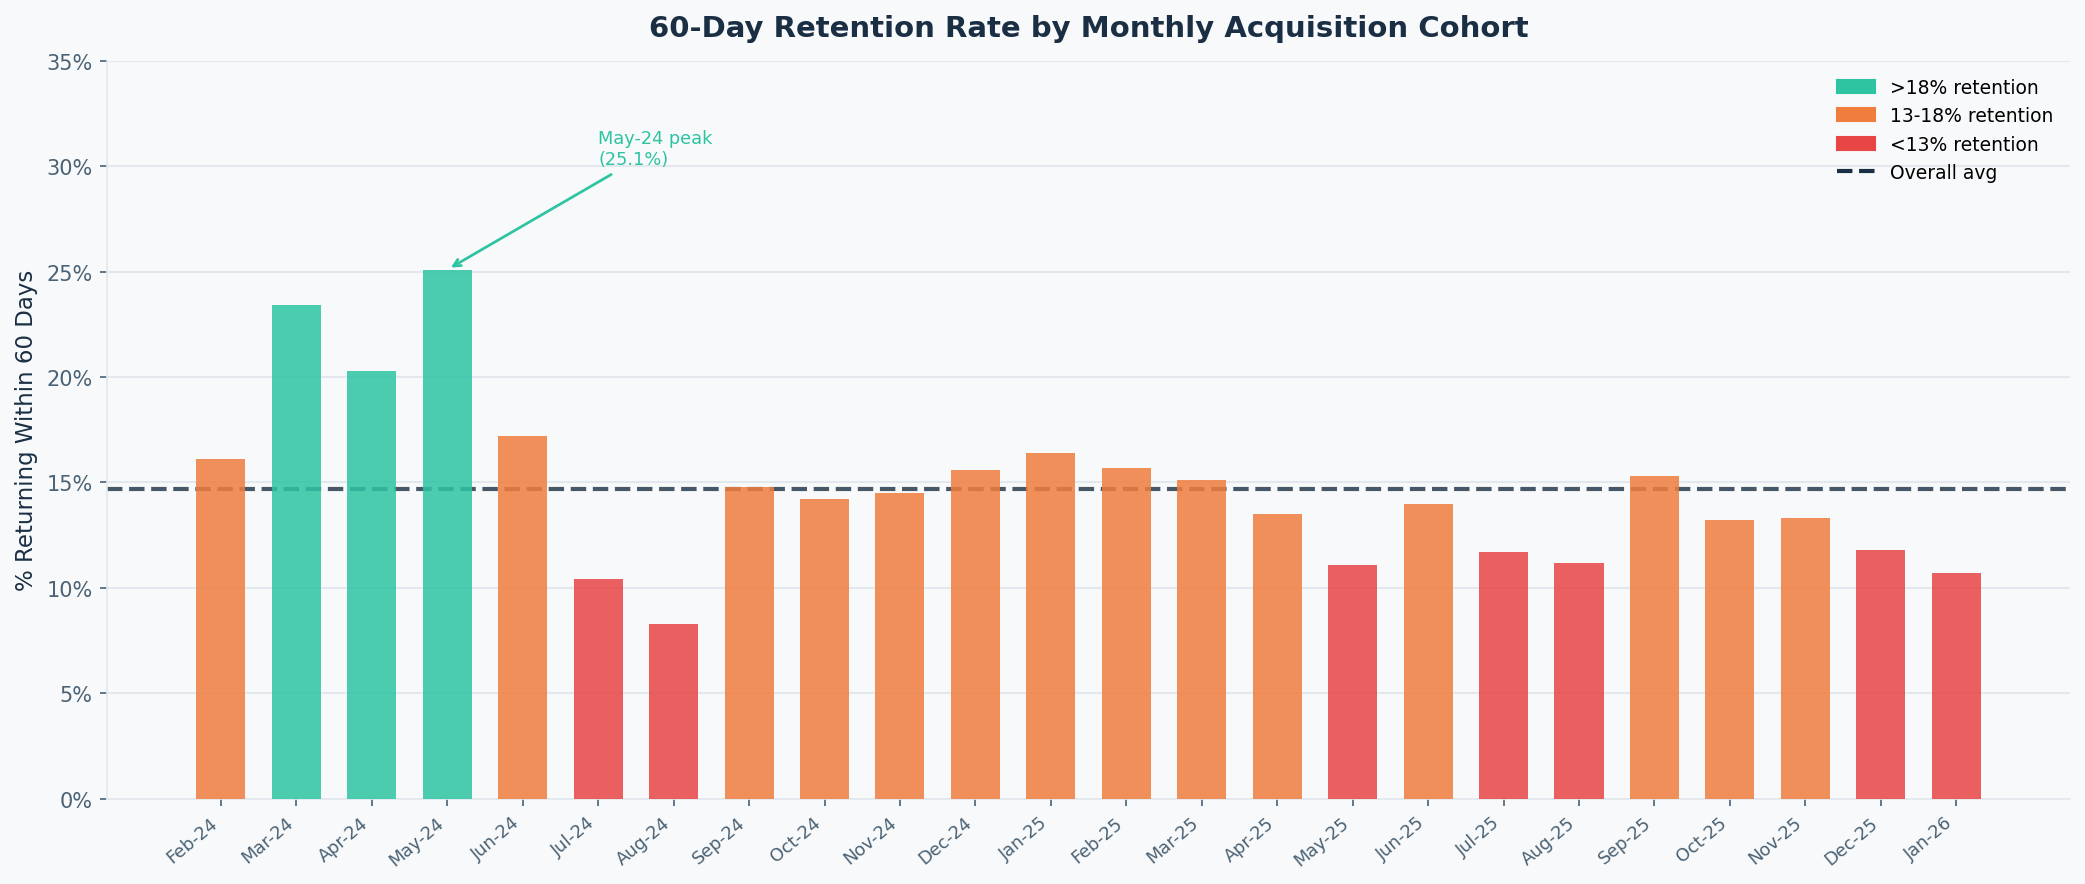

  Displayed inline: 02d_cohort_60d_retention
Done – 02_retention_overview


In [6]:
# ── Chart 4: Monthly cohort 60-day retention ─────────────────────────────────
cohort_labels = [
    "Feb-24","Mar-24","Apr-24","May-24","Jun-24","Jul-24",
    "Aug-24","Sep-24","Oct-24","Nov-24","Dec-24",
    "Jan-25","Feb-25","Mar-25","Apr-25","May-25","Jun-25",
    "Jul-25","Aug-25","Sep-25","Oct-25","Nov-25","Dec-25","Jan-26",
]
retention_60d = [
    16.1, 23.4, 20.3, 25.1, 17.2, 10.4,
    8.3, 14.8, 14.2, 14.5, 15.6,
    16.4, 15.7, 15.1, 13.5, 11.1, 14.0,
    11.7, 11.2, 15.3, 13.2, 13.3, 11.8, 10.7,
]
cohort_sizes = [
    57,111,148,182,154,385,
    315,230,141,145,93,
    53,69,139,420,425,362,
    391,332,303,364,494,172,224,
]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(cohort_labels))
bar_colors = [TEAL if r > 18 else ORANGE if r > 13 else RED for r in retention_60d]
bars = ax.bar(x, retention_60d, color=bar_colors, width=0.65, zorder=3, alpha=0.85)
avg_60d = sum(retention_60d) / len(retention_60d)
ax.axhline(avg_60d, color=NAVY, linewidth=2, linestyle="--", alpha=0.8, label=f"Overall avg {avg_60d:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(cohort_labels, rotation=40, ha="right", fontsize=8.5)
ax.set_title("60-Day Retention Rate by Monthly Acquisition Cohort")
ax.set_ylabel("% Returning Within 60 Days", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.set_ylim(0, 35)
ax.legend(fontsize=10)

# Annotate notable points
peak_idx = retention_60d.index(max(retention_60d))
ax.annotate(f"{cohort_labels[peak_idx]} peak\n({retention_60d[peak_idx]:.1f}%)",
            xy=(peak_idx, retention_60d[peak_idx]), xytext=(peak_idx+2, retention_60d[peak_idx]+5),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.3), color=TEAL, fontsize=8.5)

patches = [
    mpatches.Patch(color=TEAL,   label=">18% retention"),
    mpatches.Patch(color=ORANGE, label="13-18% retention"),
    mpatches.Patch(color=RED,    label="<13% retention"),
]
ax.legend(handles=patches + [plt.Line2D([0],[0],color=NAVY,linewidth=2,linestyle="--",label="Overall avg")],
          loc="upper right", fontsize=9)

fig.tight_layout()
save(fig, "02d_cohort_60d_retention")

print("Done – 02_retention_overview")
